# DSCI 510 Final Project Results Notebook

This notebook runs the project pipeline and final analysis by importing functions from the `.py` files in the `src/` folder. It does not copy the full source code from those scripts. File paths, file names, and constants are imported from `config.py`.


In [1]:
# Cell 1: Set up imports for the src folder

import os
import sys

SRC_FOLDER = os.path.join(os.getcwd(), "src")

if SRC_FOLDER not in sys.path:
    sys.path.append(SRC_FOLDER)


In [3]:
# Cell 2: Import constants from config.py

from config import (
    DATA_FOLDER,
    RESULTS_FOLDER,
    FINAL_COMBINED_OUTPUT,
    DATASET_SUMMARY_OUTPUT,
    SOURCE_SUMMARY_OUTPUT,
    SUBCATEGORY_SUMMARY_OUTPUT,
    CORRELATION_OUTPUT,
    CORRELATION_BY_SOURCE_OUTPUT,
    HYPOTHESIS_TESTS_OUTPUT,
    LINEAR_REGRESSION_OUTPUT,
    VIF_OUTPUT,
    RANDOM_FOREST_RESULTS_OUTPUT,
    RANDOM_FOREST_FEATURE_IMPORTANCE_OUTPUT,
    API_COMPARISON_SUMMARY_OUTPUT,
    BEST_SELLERS_COMPARISON_SUMMARY_OUTPUT,
    WRITTEN_SUMMARY_OUTPUT,
    PRICE_DISTRIBUTION_PLOT,
    RATING_DISTRIBUTION_PLOT,
    PRICE_VS_RATING_PLOT,
    REVIEWCOUNT_VS_RATING_PLOT,
    AVERAGE_PRICE_BY_SOURCE_PLOT,
    AVERAGE_RATING_BY_SOURCE_PLOT,
    PRODUCT_COUNT_BY_SOURCE_PLOT,
    LOG_PRICE_BY_SOURCE_PLOT,
    RATING_BY_SOURCE_PLOT,
    REGRESSION_RESIDUALS_VS_FITTED_PLOT,
    REGRESSION_RESIDUAL_HISTOGRAM_PLOT,
    REGRESSION_QQ_PLOT,
    RANDOM_FOREST_FEATURE_IMPORTANCE_PLOT,
    API_COMPARISON_AVERAGE_RATING_PLOT,
    BEST_SELLERS_AVERAGE_RATING_PLOT
)


In [4]:
# Cell 3: Import functions from Python scripts in src/

from api_fetch import save_dummyjson_products
from clean_data import main as clean_data_main
from final_analysis import (
    create_folder,
    load_all_final_datasets,
    clean_combined_dataset,
    save_dataset_summary,
    save_source_summary,
    save_subcategory_summary,
    plot_price_distribution,
    plot_rating_distribution,
    plot_price_vs_rating,
    plot_reviewcount_vs_rating,
    plot_average_price_by_source,
    plot_average_rating_by_source,
    plot_product_count_by_source,
    plot_log_price_by_source,
    plot_rating_by_source,
    run_correlation_analysis,
    run_correlation_by_source,
    run_hypothesis_tests,
    run_linear_regression,
    save_vif_results,
    save_regression_diagnostic_plots,
    run_random_forest_model,
    save_api_comparison,
    save_best_sellers_comparison,
    create_written_summary
)
from tests import (
    test_final_cleaned_files_exist,
    test_final_cleaned_data_schema,
    test_numeric_columns,
    test_final_result_files_exist
)

import pandas as pd
from IPython.display import Image, display


## Step 1: Fetch API data

This cell fetches DummyJSON product data using the function from `api_fetch.py`.


In [5]:
# Cell 4: Fetch DummyJSON API data and save it to data/

dummyjson_df = save_dummyjson_products()
dummyjson_df.head()


DummyJSON API data saved successfully.
Output file: /Users/yulai/Desktop/DSCI_510_Final_Project/data/dummyjson_products.csv
Shape: (194, 6)

Preview:
                    product_name  price  rating  review_count category  \
0  Essence Mascara Lash Princess   9.99    2.56             3   beauty   
1  Eyeshadow Palette with Mirror  19.99    2.86             3   beauty   
2                Powder Canister  14.99    4.64             3   beauty   
3                   Red Lipstick  12.99    4.36             3   beauty   
4                Red Nail Polish   8.99    4.32             3   beauty   

          source  
0  dummyjson_api  
1  dummyjson_api  
2  dummyjson_api  
3  dummyjson_api  
4  dummyjson_api  


,product_name,price,rating,review_count,category,source
0,Essence Mascara Lash Princess,9.99,2.56,3,beauty,dummyjson_api
1,Eyeshadow Palette with Mirror,19.99,2.86,3,beauty,dummyjson_api
2,Powder Canister,14.99,4.64,3,beauty,dummyjson_api
3,Red Lipstick,12.99,4.36,3,beauty,dummyjson_api
4,Red Nail Polish,8.99,4.32,3,beauty,dummyjson_api


## Step 2: Clean all datasets

This cell runs the combined cleaning script from `clean_data.py`. It creates the four final cleaned CSV files used in analysis.


In [6]:
# Cell 5: Clean all datasets

clean_data_main()


Starting data cleaning
Reading: /Users/yulai/Desktop/DSCI_510_Final_Project/data/All_Electronics.csv
Reading: /Users/yulai/Desktop/DSCI_510_Final_Project/data/Home_Entertainment_Systems.csv

All Electronics cleaned
Shape: (8233, 7)
Columns: ['product_name', 'price', 'rating', 'review_count', 'category', 'subcategory', 'source']
Preview:
                                        product_name    price  rating  \
0  Redmi 10 Power (Power Black, 8GB RAM, 128GB St...  10999.0     4.0   
1  OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...  18999.0     4.3   
2  OnePlus Bullets Z2 Bluetooth Wireless in Ear E...   1999.0     4.2   
3  Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...  15999.0     4.1   
4  OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...  18999.0     4.3   

   review_count             category      subcategory               source  
0         965.0  tv, audio & cameras  All Electronics  all_electronics_csv  
1      113956.0  tv, audio & cameras  All Electronics  all_electroni

## Step 3: Load final cleaned datasets

This cell imports the final cleaned datasets using functions from `final_analysis.py`.


In [7]:
# Cell 6: Load and clean combined final dataset

create_folder(RESULTS_FOLDER)

raw_df = load_all_final_datasets()
df = clean_combined_dataset(raw_df)

final_combined_file = os.path.join(DATA_FOLDER, FINAL_COMBINED_OUTPUT)
df.to_csv(final_combined_file, index=False)

print("Raw combined shape:", raw_df.shape)
print("Cleaned combined shape:", df.shape)
print("Final combined file saved to:", final_combined_file)

df.head()


Raw combined shape: (16018, 7)
Cleaned combined shape: (16018, 11)
Final combined file saved to: /Users/yulai/Desktop/DSCI_510_Final_Project/data/final_combined_products_final.csv


,product_name,price,rating,review_count,category,subcategory,source,source_label,data_role,log_price,log_review_count
0,"Redmi 10 Power (Power Black, 8GB RAM, 128GB St...",10999.0,4.0,965.0,"tv, audio & cameras",All Electronics,all_electronics_csv,All Electronics CSV,main_amazon_csv,9.305651,6.873164
1,"OnePlus Nord CE 2 Lite 5G (Blue Tide, 6GB RAM,...",18999.0,4.3,113956.0,"tv, audio & cameras",All Electronics,all_electronics_csv,All Electronics CSV,main_amazon_csv,9.852194,11.643576
2,OnePlus Bullets Z2 Bluetooth Wireless in Ear E...,1999.0,4.2,90304.0,"tv, audio & cameras",All Electronics,all_electronics_csv,All Electronics CSV,main_amazon_csv,7.600902,11.410948
3,"Samsung Galaxy M33 5G (Mystique Green, 6GB, 12...",15999.0,4.1,24863.0,"tv, audio & cameras",All Electronics,all_electronics_csv,All Electronics CSV,main_amazon_csv,9.680344,10.121176
4,"OnePlus Nord CE 2 Lite 5G (Black Dusk, 6GB RAM...",18999.0,4.3,113956.0,"tv, audio & cameras",All Electronics,all_electronics_csv,All Electronics CSV,main_amazon_csv,9.852194,11.643576


## Step 4: Presentation-stage summaries and visualizations

These functions reproduce the presentation-stage summaries and plots.


In [8]:
# Cell 7: Create dataset, source, and subcategory summaries

dataset_summary = save_dataset_summary(df)
source_summary = save_source_summary(df)
subcategory_summary = save_subcategory_summary(df)

display(dataset_summary)
display(source_summary)
display(subcategory_summary.head(10))


,metric,value
0,number_of_products,16016.0000
1,number_of_sources,4.0000
2,number_of_subcategories,9.0000
3,mean_price,2859.5000
4,median_price,449.0000
5,max_price,249990.0000
6,mean_rating,4.0000
7,median_rating,4.1000
8,mean_review_count,6022.2800
9,median_review_count,280.0000


,source,source_label,data_role,product_count,mean_price,median_price,price_q1,price_q3,mean_rating,median_rating,mean_review_count,median_review_count
0,all_electronics_csv,All Electronics CSV,main_amazon_csv,8233,3066.67,559.00,299.00,1590.00,4.07,4.10,8661.97,1088.0
1,amazon_webpage,Amazon Best Sellers Web,amazon_best_sellers_web,298,66.48,22.60,9.99,58.71,4.48,4.50,33497.29,11706.0
2,dummyjson_api,DummyJSON API,dummyjson_api,193,1495.34,34.99,11.99,249.99,3.80,3.86,3.00,3.0
3,home_entertainment_csv,Home Entertainment CSV,main_amazon_csv,7292,2775.84,419.00,299.00,885.75,3.90,4.00,2078.46,38.0


,subcategory,source_label,product_count,mean_price,median_price,mean_rating,median_rating,mean_review_count,median_review_count
0,All Electronics,All Electronics CSV,8233,3066.67,559.00,4.07,4.10,8661.97,1088.0
7,Home Entertainment Systems,Home Entertainment CSV,7292,2775.84,419.00,3.90,4.00,2078.46,38.0
4,DummyJSON Products,DummyJSON API,193,1495.34,34.99,3.80,3.86,3.00,3.0
2,Cell Phones & Accessories,Amazon Best Sellers Web,59,15.79,9.99,4.51,4.50,78179.51,23810.0
5,Electronics,Amazon Best Sellers Web,57,83.89,25.99,4.57,4.60,40097.67,18676.0
1,Camera & Photo,Amazon Best Sellers Web,56,85.28,43.99,4.44,4.40,12972.23,5539.0
3,Computers & Accessories,Amazon Best Sellers Web,56,103.25,25.08,4.46,4.50,8750.39,4812.5
6,Headphones & Earbuds,Amazon Best Sellers Web,46,65.35,24.44,4.37,4.40,21877.41,12235.5
8,Televisions & Video Products,Amazon Best Sellers Web,24,22.21,9.18,4.55,4.60,35883.54,16854.5


In [9]:
# Cell 8: Create presentation-stage plots

plot_price_distribution(df)
plot_rating_distribution(df)
plot_price_vs_rating(df)
plot_reviewcount_vs_rating(df)
plot_average_price_by_source(source_summary)
plot_average_rating_by_source(source_summary)
plot_product_count_by_source(source_summary)

print("Presentation-stage plots saved to:", RESULTS_FOLDER)


Presentation-stage plots saved to: /Users/yulai/Desktop/DSCI_510_Final_Project/results


price_distribution_final.png


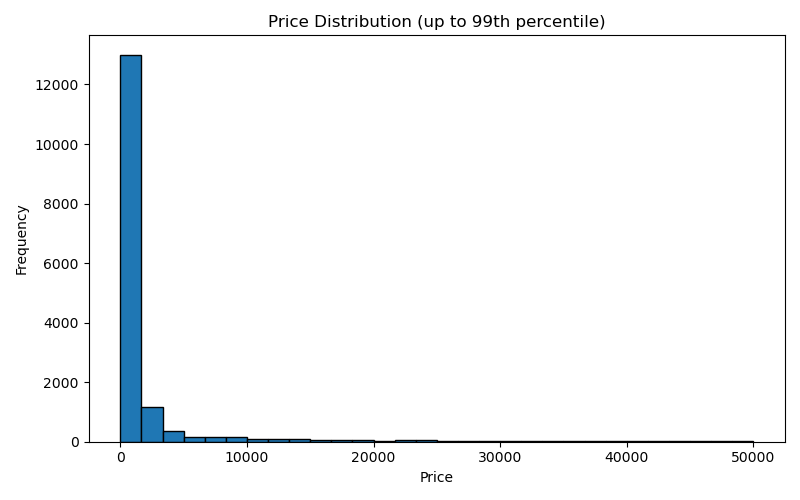

rating_distribution_final.png


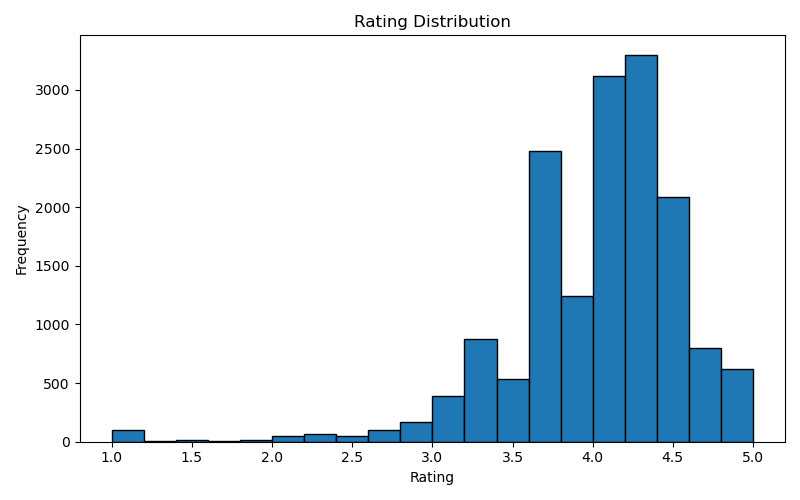

price_vs_rating_final.png


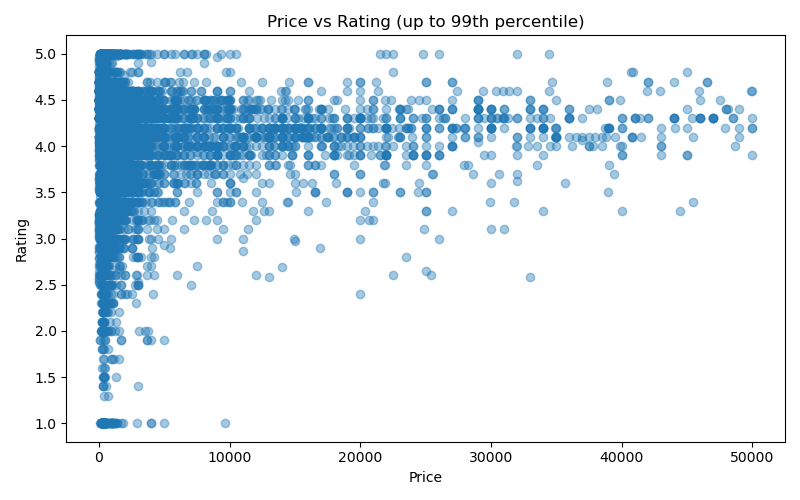

reviewcount_vs_rating_final.png


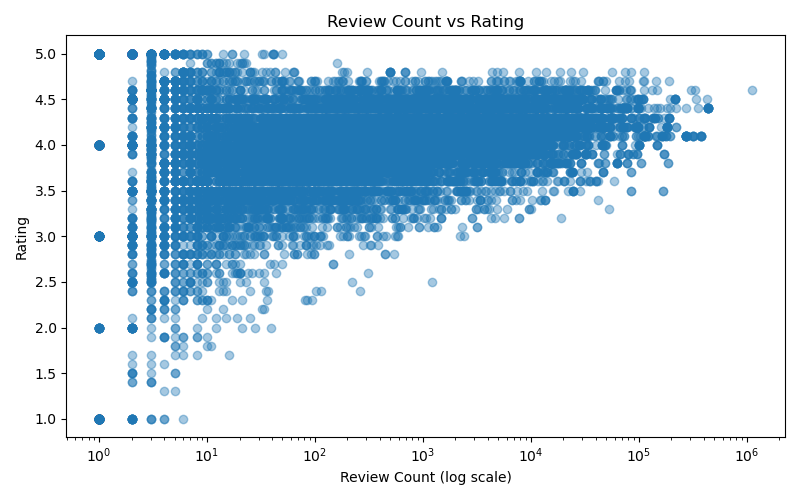

average_price_by_source_final.png


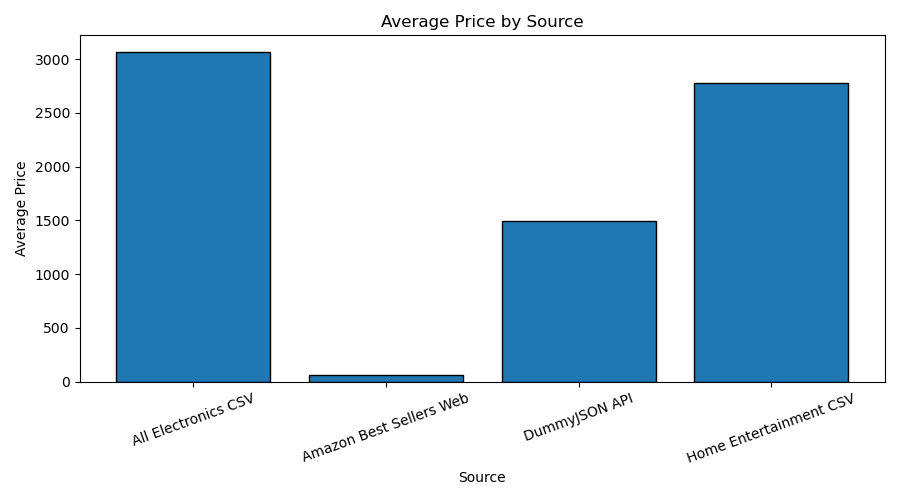

average_rating_by_source_final.png


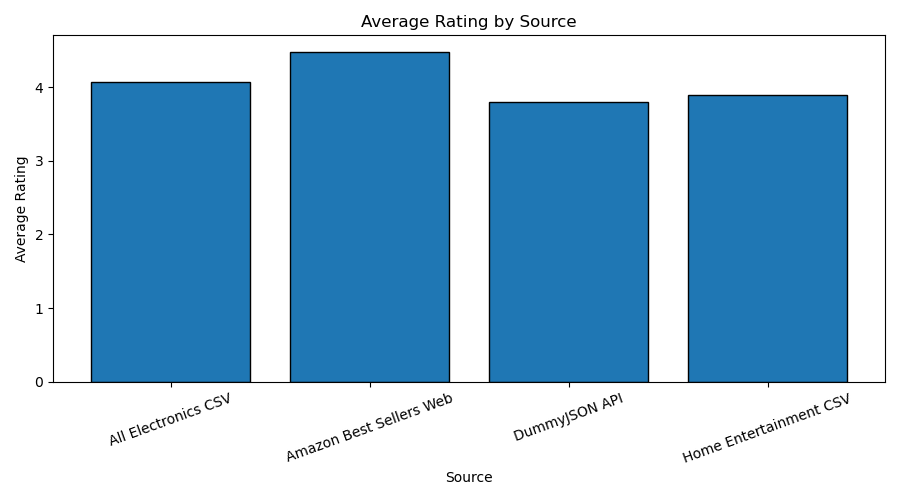

product_count_by_source_final.png


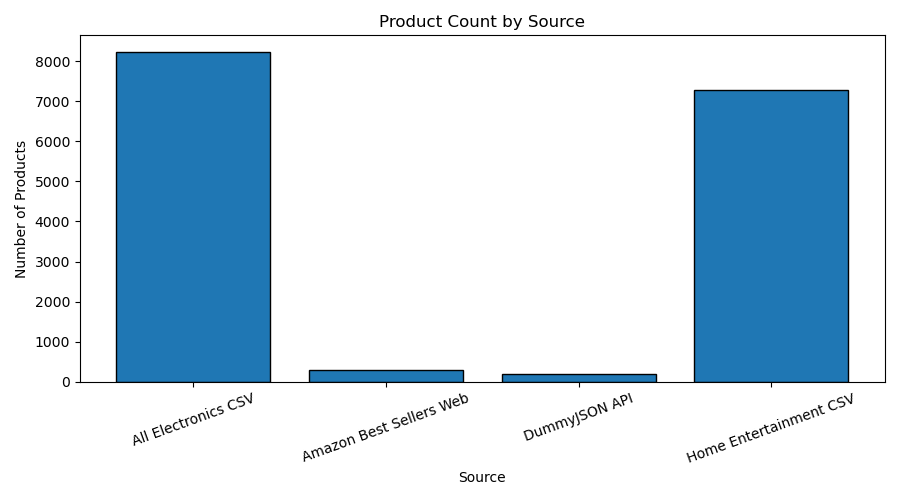

In [10]:
# Cell 9: Display presentation-stage plots

presentation_plots = [
    PRICE_DISTRIBUTION_PLOT,
    RATING_DISTRIBUTION_PLOT,
    PRICE_VS_RATING_PLOT,
    REVIEWCOUNT_VS_RATING_PLOT,
    AVERAGE_PRICE_BY_SOURCE_PLOT,
    AVERAGE_RATING_BY_SOURCE_PLOT,
    PRODUCT_COUNT_BY_SOURCE_PLOT
]

for plot_name in presentation_plots:
    print(plot_name)
    display(Image(filename=os.path.join(RESULTS_FOLDER, plot_name)))


## Step 5: Final-stage distribution comparisons

These functions add the final-stage source-level comparison plots.


log_price_by_source_final.png


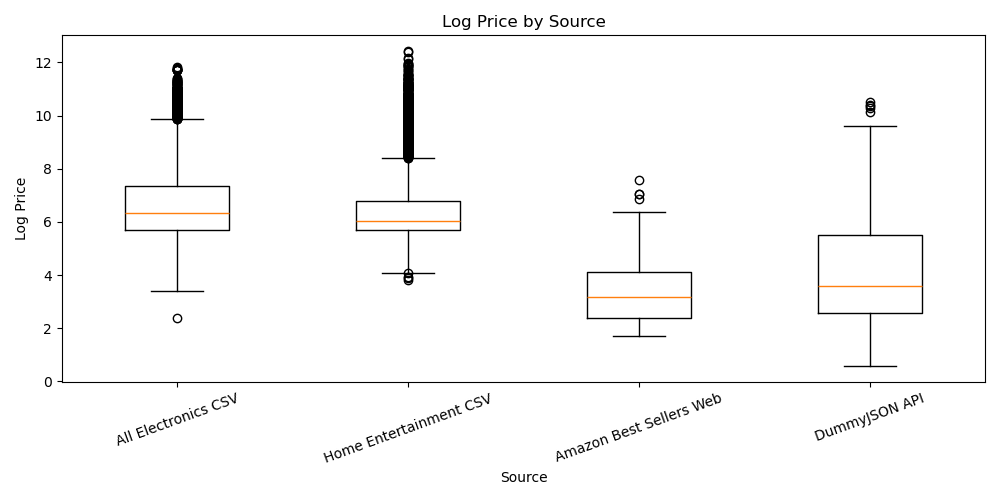

rating_by_source_final.png


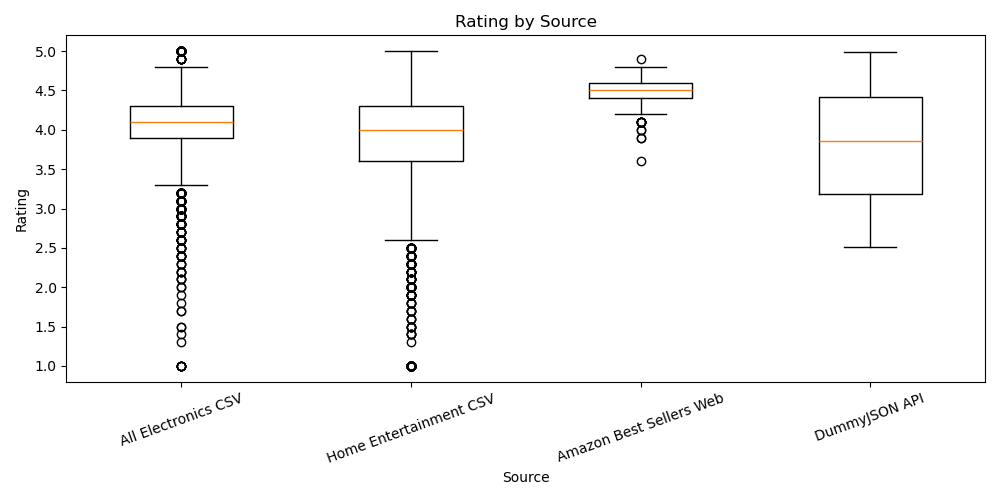

In [11]:
# Cell 10: Create and display final-stage source comparison plots

plot_log_price_by_source(df)
plot_rating_by_source(df)

source_comparison_plots = [
    LOG_PRICE_BY_SOURCE_PLOT,
    RATING_BY_SOURCE_PLOT
]

for plot_name in source_comparison_plots:
    print(plot_name)
    display(Image(filename=os.path.join(RESULTS_FOLDER, plot_name)))


## Step 6: Correlation analysis

These cells run Pearson and Spearman correlation analyses using functions from `final_analysis.py`.


In [12]:
# Cell 11: Run correlation analysis

correlation_results = run_correlation_analysis(df)
correlation_by_source = run_correlation_by_source(df)

display(correlation_results)
display(correlation_by_source)


/Users/yulai/Desktop/DSCI_510_Final_Project/src/final_analysis.py:521: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  reviews_rating = stats.spearmanr(source_df["log_review_count"], source_df["rating"])


,variable_1,variable_2,pearson_correlation,pearson_p_value,spearman_correlation,spearman_p_value
0,price,rating,0.0905,1.861556e-30,0.0950,1.888841e-33
1,price,review_count,-0.0072,3.617808e-01,0.1599,3.790473e-92
2,price,log_price,0.6339,0.000000e+00,1.0000,0.000000e+00
3,price,log_review_count,0.0538,9.381476e-12,0.1599,3.790473e-92
4,rating,review_count,0.0958,5.729678e-34,0.2271,1.802913e-186
5,rating,log_price,0.0729,2.608897e-20,0.0950,1.888841e-33
6,rating,log_review_count,0.2467,1.048169e-220,0.2271,1.802913e-186
7,review_count,log_price,0.0031,6.913399e-01,0.1599,3.790473e-92
8,review_count,log_review_count,0.4262,0.000000e+00,1.0000,0.000000e+00
9,log_price,log_review_count,0.1352,3.117566e-66,0.1599,3.790473e-92


,source,source_label,n,spearman_log_price_rating,p_value_log_price_rating,spearman_log_review_count_rating,p_value_log_review_count_rating
0,all_electronics_csv,All Electronics CSV,8233,0.0827,5.641619e-14,0.1673,1.020585e-52
1,home_entertainment_csv,Home Entertainment CSV,7292,0.1713,3.948507e-49,0.1210,3.282185e-25
2,amazon_webpage,Amazon Best Sellers Web,298,-0.1122,5.304647e-02,0.1433,1.327526e-02
3,dummyjson_api,DummyJSON API,193,-0.0509,4.822465e-01,NaN,NaN


## Step 7: Hypothesis testing

This cell runs group comparison tests between data sources.


In [13]:
# Cell 12: Run hypothesis tests

hypothesis_results = run_hypothesis_tests(df)
display(hypothesis_results)


/opt/anaconda3/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,test_name,variable,group_1,group_2,group_1_n,group_2_n,group_1_mean,group_2_mean,statistic,p_value,interpretation,group_1_median,group_2_median
0,Main CSV source comparison - Welch t-test,log_price,All Electronics CSV,Home Entertainment CSV,8233,7292,6.6670,6.4170,1.180894e+01,4.812819e-32,Reject H0: statistically significant difference,NaN,NaN
1,Main CSV source comparison - Mann-Whitney U test,log_price,All Electronics CSV,Home Entertainment CSV,8233,7292,NaN,NaN,3.335124e+07,5.483771e-33,Reject H0: statistically significant difference,6.3279,6.0403
2,Main CSV source comparison - Welch t-test,rating,All Electronics CSV,Home Entertainment CSV,8233,7292,4.0712,3.9009,1.911595e+01,3.422754e-80,Reject H0: statistically significant difference,NaN,NaN
3,Main CSV source comparison - Mann-Whitney U test,rating,All Electronics CSV,Home Entertainment CSV,8233,7292,NaN,NaN,3.506601e+07,9.258377e-74,Reject H0: statistically significant difference,4.1000,4.0000
4,Main CSV source comparison - Welch t-test,log_review_count,All Electronics CSV,Home Entertainment CSV,8233,7292,6.8878,4.0581,7.340986e+01,0.000000e+00,Reject H0: statistically significant difference,NaN,NaN
5,Main CSV source comparison - Mann-Whitney U test,log_review_count,All Electronics CSV,Home Entertainment CSV,8233,7292,NaN,NaN,4.795596e+07,0.000000e+00,Reject H0: statistically significant difference,6.9930,3.6636
6,Best Sellers comparison - Welch t-test,log_price,Main Amazon CSV Data,Amazon Best Sellers Web,15525,300,6.5496,3.4121,4.795157e+01,5.904339e-147,Reject H0: statistically significant difference,NaN,NaN
7,Best Sellers comparison - Mann-Whitney U test,log_price,Main Amazon CSV Data,Amazon Best Sellers Web,15525,300,NaN,NaN,4.521052e+06,3.023559e-172,Reject H0: statistically significant difference,6.1377,3.1778
8,Best Sellers comparison - Welch t-test,rating,Main Amazon CSV Data,Amazon Best Sellers Web,15525,300,3.9912,4.4800,-4.311619e+01,9.090422e-155,Reject H0: statistically significant difference,NaN,NaN
9,Best Sellers comparison - Mann-Whitney U test,rating,Main Amazon CSV Data,Amazon Best Sellers Web,15525,300,NaN,NaN,7.022385e+05,3.253018e-96,Reject H0: statistically significant difference,4.1000,4.5000


## Step 8: Multiple linear regression and diagnostics

These cells run the multiple linear regression model and create diagnostic plots.


In [14]:
# Cell 13: Run linear regression and VIF

regression_model, X, y = run_linear_regression(df)
vif_results = save_vif_results(X)
save_regression_diagnostic_plots(regression_model)

print(regression_model.summary())
display(vif_results)


                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     255.5
Date:                Wed, 06 May 2026   Prob (F-statistic):          1.26e-263
Time:                        09:19:26   Log-Likelihood:                -12428.
No. Observations:               16016   AIC:                         2.487e+04
Df Residuals:                   16010   BIC:                         2.491e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

,variable,VIF
0,const,31.646747
1,log_price,1.172980
2,log_review_count,1.464591
3,source_amazon_webpage,1.162596
4,source_dummyjson_api,1.104433
5,source_home_entertainment_csv,1.383454


regression_residuals_vs_fitted_final.png


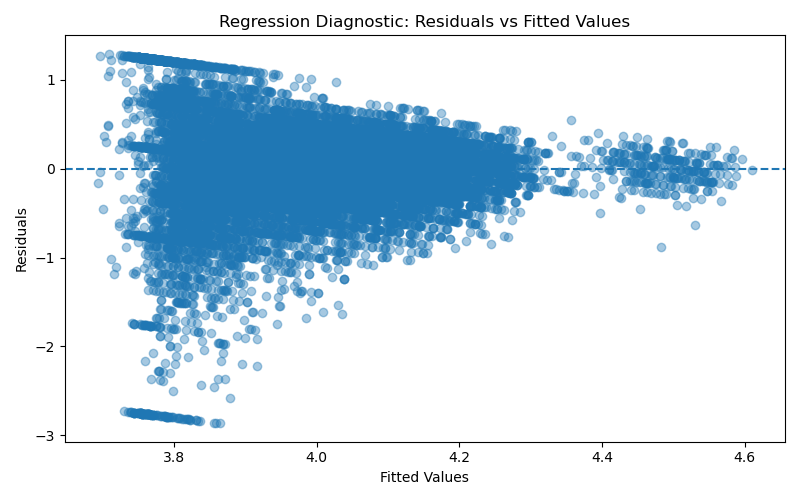

regression_residual_histogram_final.png


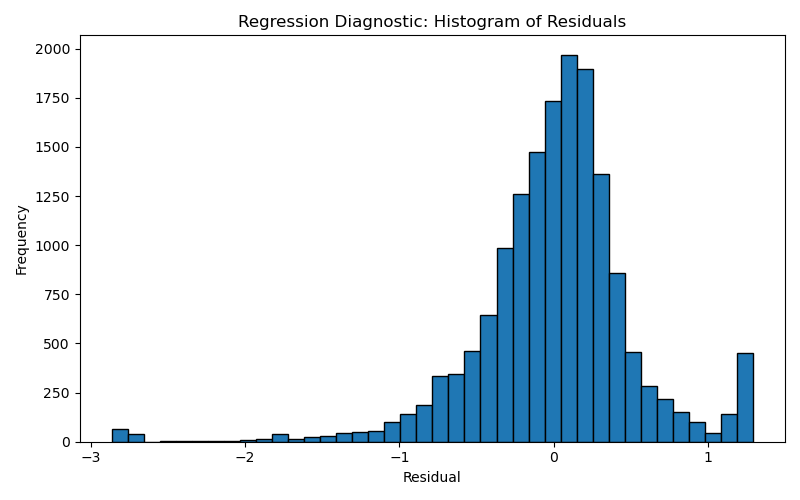

regression_qq_plot_final.png


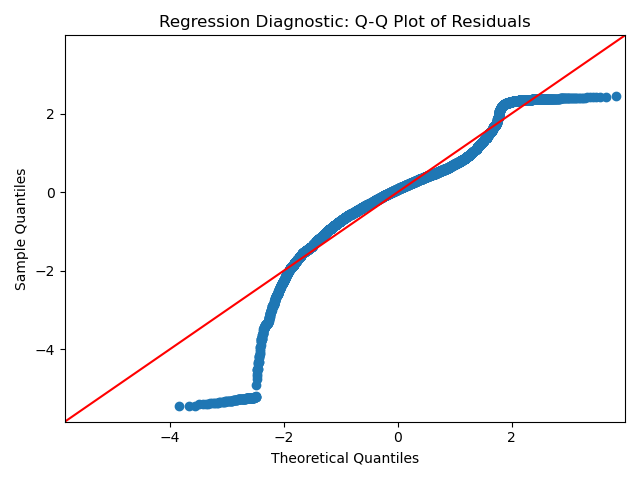

In [15]:
# Cell 14: Display regression diagnostic plots

regression_plots = [
    REGRESSION_RESIDUALS_VS_FITTED_PLOT,
    REGRESSION_RESIDUAL_HISTOGRAM_PLOT,
    REGRESSION_QQ_PLOT
]

for plot_name in regression_plots:
    print(plot_name)
    display(Image(filename=os.path.join(RESULTS_FOLDER, plot_name)))


## Step 9: Random Forest regression

This cell runs the Random Forest model using the function from `final_analysis.py`.


,model,target,number_of_rows_used,test_size,MAE,RMSE,R_squared
0,Random Forest Regression,rating,16016,3204,0.343576,0.506275,0.096312


,feature,importance
0,log_price,0.485714
1,log_review_count,0.443266
2,source_amazon_webpage,0.027999
4,source_home_entertainment_csv,0.018740
11,subcategory_Home Entertainment Systems,0.017994
3,source_dummyjson_api,0.002587
8,subcategory_DummyJSON Products,0.002179
10,subcategory_Headphones & Earbuds,0.000713
9,subcategory_Electronics,0.000318
7,subcategory_Computers & Accessories,0.000165


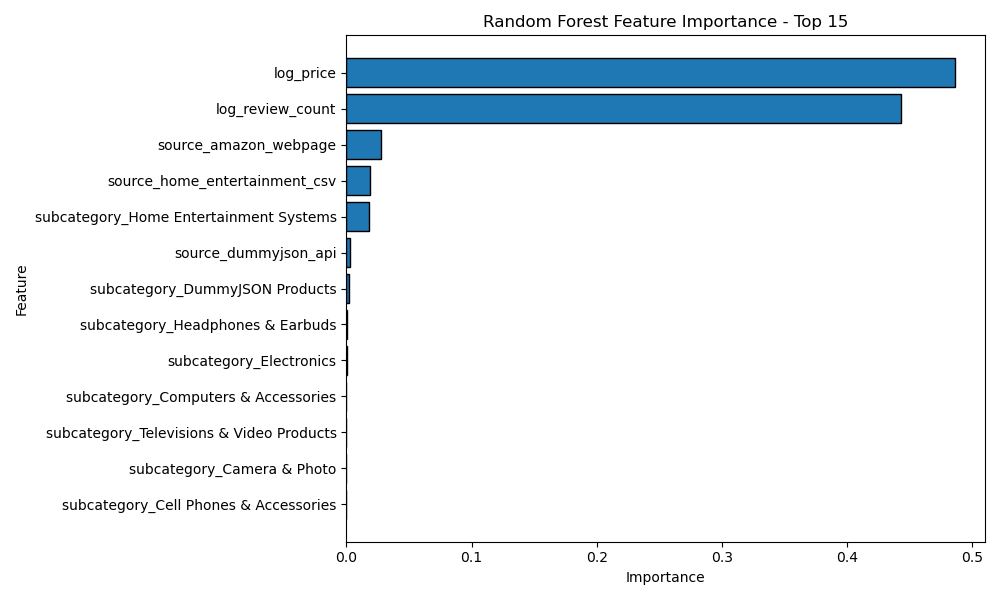

In [16]:
# Cell 15: Run Random Forest regression model

rf_results, feature_importance = run_random_forest_model(df)

display(rf_results)
display(feature_importance.head(15))
display(Image(filename=os.path.join(RESULTS_FOLDER, RANDOM_FOREST_FEATURE_IMPORTANCE_PLOT)))


## Step 10: API comparison and Best Sellers comparison

These cells use DummyJSON as the API-based comparison dataset and Amazon Best Sellers as the web-scraped comparison dataset.


In [17]:
# Cell 16: Run API and Best Sellers comparison

api_summary = save_api_comparison(df)
best_sellers_summary = save_best_sellers_comparison(df)

display(api_summary)
display(best_sellers_summary)


,comparison_group,product_count,mean_price,median_price,mean_rating,median_rating,mean_review_count,median_review_count
0,Amazon Sources,15823,2876.14,449.00,4.0,4.10,6095.7,292.0
1,DummyJSON API,193,1495.34,34.99,3.8,3.86,3.0,3.0


,comparison_group,product_count,mean_price,median_price,mean_rating,median_rating,mean_review_count,median_review_count
0,Amazon Best Sellers Web,298,66.48,22.6,4.48,4.5,33497.29,11706.0
1,Main Amazon CSV Data,15525,2930.07,462.0,3.99,4.1,5569.73,274.0


In [ ]:
# Cell 17: Display API and Best Sellers comparison plots

comparison_plots = [
    API_COMPARISON_AVERAGE_RATING_PLOT,
    BEST_SELLERS_AVERAGE_RATING_PLOT
]

for plot_name in comparison_plots:
    print(plot_name)
    display(Image(filename=os.path.join(RESULTS_FOLDER, plot_name)))


## Step 11: Written summary

This cell creates a short written summary for the final project results.


In [18]:
# Cell 18: Create and display written summary

written_summary = create_written_summary(
    df,
    dataset_summary,
    source_summary,
    rf_results
)

print(written_summary)



DSCI 510 Final Analysis Summary

The final analysis uses four cleaned datasets: All Electronics CSV, Home Entertainment
CSV, Amazon Best Sellers web-scraped data, and DummyJSON API data. After cleaning,
the analysis dataset contains 16016 products from 4 sources.

The overall mean price is 2859.50, while the median price is 449.00.
This confirms that product price is strongly right-skewed. The overall mean rating is
4.00, and the median rating is 4.10, showing that most
ratings are concentrated near the high end of the 0-5 scale. The mean review count is
6022.28, while the median review count is 280.00, which also
shows a right-skewed pattern.

Compared with the presentation-stage analysis, this final stage adds log transformation,
Pearson and Spearman correlation analysis, hypothesis testing, multiple linear regression,
regression diagnostics, and a Random Forest regression model. DummyJSON is used as
an API-based comparison dataset, while Amazon Best Sellers is used as a supplementa

## Step 12: Run project tests

These tests check the cleaned files, schema, numeric columns, and final result files. The API test is already covered by the API fetch step at the beginning of this notebook.


In [19]:
# Cell 19: Run final project tests

test_final_cleaned_files_exist()
test_final_cleaned_data_schema()
test_numeric_columns()
test_final_result_files_exist()

print("Notebook pipeline completed successfully.")


Checking whether final cleaned CSV files exist...
Found: /Users/yulai/Desktop/DSCI_510_Final_Project/data/all_electronics_cleaned_for_final.csv
Found: /Users/yulai/Desktop/DSCI_510_Final_Project/data/home_entertainment_cleaned_for_final.csv
Found: /Users/yulai/Desktop/DSCI_510_Final_Project/data/dummyjson_products_cleaned_for_final.csv
Found: /Users/yulai/Desktop/DSCI_510_Final_Project/data/amazon_best_sellers_cleaned_for_final.csv
Final cleaned file existence test passed.
------------------------------------------------------------
Checking final cleaned data schema...
all_electronics_cleaned_for_final.csv
Shape: (8233, 7)
Columns OK
home_entertainment_cleaned_for_final.csv
Shape: (7292, 7)
Columns OK
dummyjson_products_cleaned_for_final.csv
Shape: (193, 7)
Columns OK
amazon_best_sellers_cleaned_for_final.csv
Shape: (300, 7)
Columns OK
Final cleaned data schema test passed.
------------------------------------------------------------
Checking numeric columns...
all_electronics_cleaned